In [1]:
import torch
import numpy as np
import pandas as pd
from epiweeks import Week
import seaborn as sns
import preprocess_data as prep
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

pd.options.mode.chained_assignment = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

columns_to_normalize = ['casos','epiweek', 'biome', 'enso']

predict_n = 52
max_epiweek = 22
    
boxcox = False

TEST_YEAR = 2026

In [2]:
batch_size = 1
doenca = 'dengue'
min_delta = 0.0
patience= 20
lr = 5e-4
min_year = 2015
model_name = 'enso_22_26_V3'

filename = f'./data/{doenca}.csv.gz'

df = prep.load_cases_data(filename)

df = df.loc[df.epiweek <= int(f'{TEST_YEAR}{max_epiweek}')]

enso = prep.load_enso_weekly(filename='data/enso_weekly_forecast_up_25_07.csv')

enso_neutro = prep.load_enso_weekly(filename='data/enso_weekly_neutro_up_25_07.csv')

Make figures: 

In [3]:
def make_figure(ax, df, region, TEST_YEAR, model_name): 

    if len(region) == 2:
        df_reg = df.loc[df.uf == region]

    else:
        df_reg = df.loc[df.uf.isin(regioes_estados[region])]

    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_preds = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv')
    df_preds.date = pd.to_datetime(df_preds.date)

    df_preds_neutro = pd.read_csv(f'predictions/preds_neutro_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv')
    df_preds_neutro.date = pd.to_datetime(df_preds_neutro.date)


    df_st_plot = df_reg.loc[(df_reg.epiweek >= 202501)]

    df_st_plot = df_st_plot.resample('W-SUN')[['casos']].sum()

    ax.plot(df_st_plot.index, df_st_plot.casos, color = 'black', label = 'Observado')

    ax.plot(df_preds.date, df_preds.pred, color = 'tab:red', label = 'El niño')

    ax.fill_between(df_preds.date, df_preds.lower_80, df_preds.upper_80, alpha=0.1,  color = 'tab:red')

    ax.plot(df_preds_neutro.date, df_preds_neutro.pred, color = 'tab:green', label = 'Neutro')

    ax.fill_between(df_preds_neutro.date, df_preds_neutro.lower_80, df_preds_neutro.upper_80, color = 'tab:green', alpha = 0.1)

    ax.set_title(region)
    ax.legend()
    ax.set_ylabel('Casos prováveis')
    ax.grid()


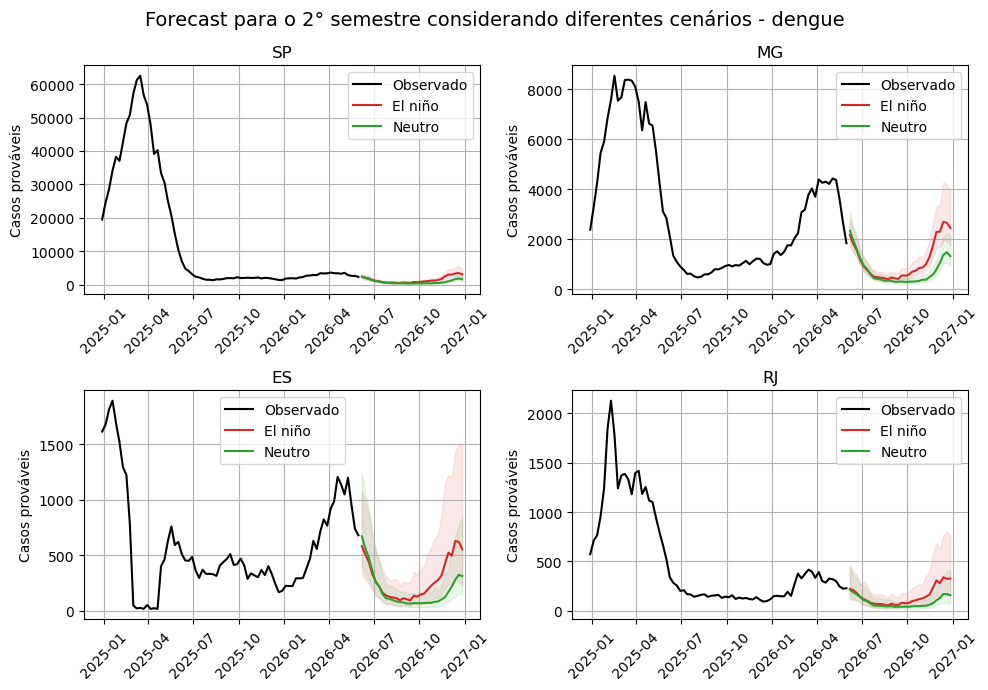

In [4]:
fig, ax = plt.subplots(2,2, figsize = (10, 7))


for r, ax in zip(['SP', 'MG', 'ES', 'RJ'], ax.ravel()): 

    make_figure(ax, df, r, TEST_YEAR, model_name)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Forecast para o 2° semestre considerando diferentes cenários - {doenca}', fontsize = 14)
plt.tight_layout()

plt.savefig(f'forecast_state_sudeste-{doenca}.png', dpi = 300, bbox_inches = 'tight')

plt.show()

In [5]:
def make_figure2(ax, df, region, TEST_YEAR, model_name): 

    if len(region) == 2:
        df_reg = df.loc[df.uf == region]

    else:
        df_reg = df.loc[df.uf.isin(regioes_estados[region])]

    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_preds = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv')
    df_preds.date = pd.to_datetime(df_preds.date)

    df_preds_neutro = pd.read_csv(f'predictions/preds_neutro_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv')
    df_preds_neutro.date = pd.to_datetime(df_preds_neutro.date)

    df_st_plot = df_reg.resample('W-SUN')[['casos']].sum()
    df_st_plot['year'] = df_st_plot.index.year
    df_st_plot['week'] = [Week.fromdate(x).week for x in df_st_plot.index]

    for year in np.arange(2020, 2026):

        df_reg_y = df_st_plot.loc[(df_st_plot.year == year) & (df_st_plot.week >= 23) & (df_st_plot.week <= 52)]
        
        ax.plot(df_preds.date, df_reg_y.casos, color = 'black', alpha = 0.25)

    ax.plot([], [], color = 'black', alpha = 0.25, label = '2020-2025')

    ax.plot(df_preds.date, df_preds.pred, color = 'tab:red', label = 'El niño')

    ax.fill_between(df_preds.date, df_preds.lower_80, df_preds.upper_80, alpha=0.1,  color = 'tab:red')

    ax.plot(df_preds_neutro.date, df_preds_neutro.pred, color = 'tab:green', label = 'Neutro')

    ax.fill_between(df_preds_neutro.date, df_preds_neutro.lower_80, df_preds_neutro.upper_80, color = 'tab:green', alpha = 0.1)

    ax.set_title(region)
    #ax.legend()
    ax.set_ylabel('Casos prováveis')
    ax.set_ylim([0, 1.25*max( df_preds.upper_80)])

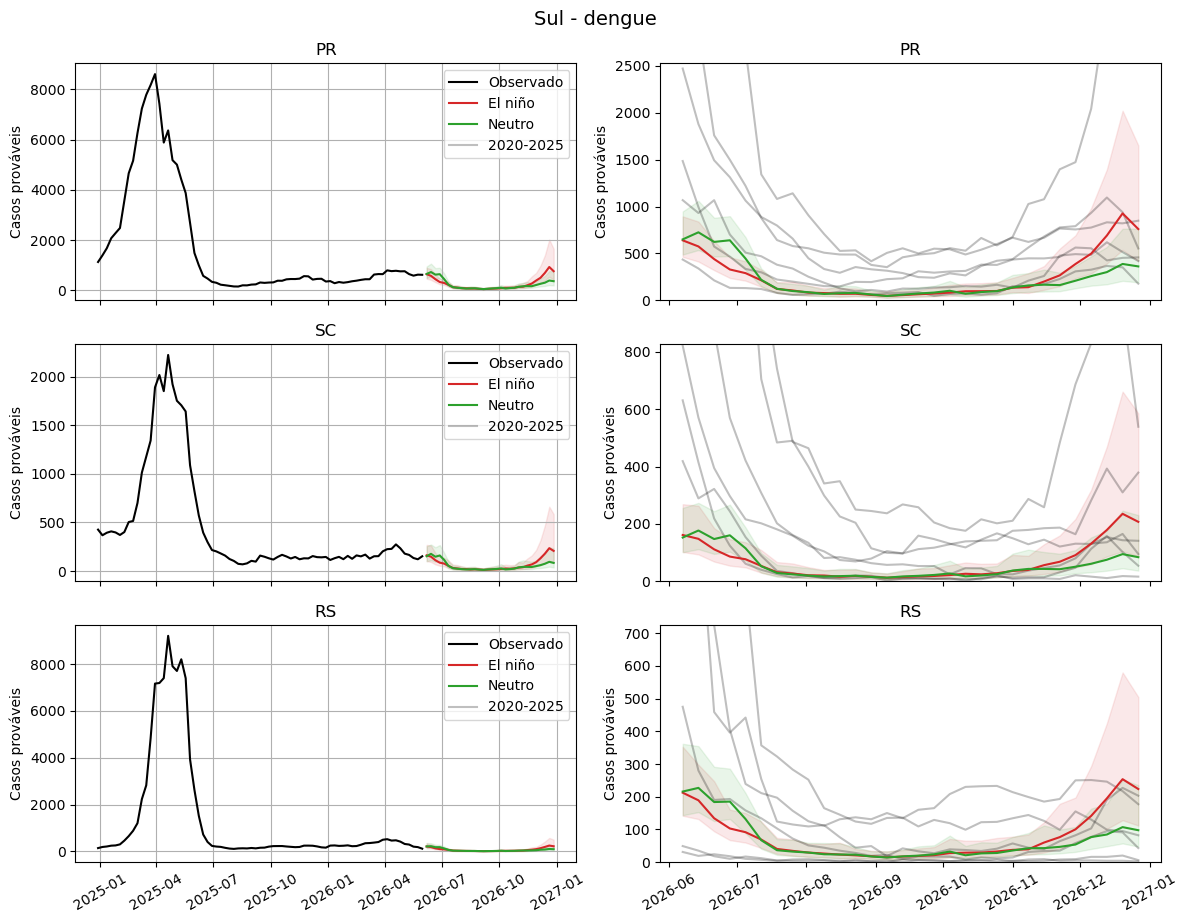

In [6]:
_,ax = plt.subplots(3,2, figsize = (12, 9), sharey = False, sharex = False)
r = 'PR'

i = 0
for r in ['PR', 'SC', 'RS']: 

    make_figure(ax[i, 0], df, r, TEST_YEAR, model_name)
    ax[i,0].tick_params(axis='x', rotation=30)

    make_figure2(ax[i, 1], df, r, TEST_YEAR, model_name)
    ax[i,1].tick_params(axis='x', rotation=30)


    handles1, labels1 = ax[i,0].get_legend_handles_labels()
    handles2, labels2 = ax[i,1].get_legend_handles_labels()

    # combina
    handles = handles1 + handles2
    labels = labels1 + labels2

    # remove duplicados preservando ordem
    unique = dict(zip(labels, handles))

    # cria legenda única
    ax[i, 0].legend(unique.values(), unique.keys(), loc="best")

    if i < 2: 
        ax[i,0].set_xticklabels([])
        ax[i,1].set_xticklabels([])


    i = i +1


plt.tight_layout()
plt.suptitle(f'Sul - {doenca}', y = 1.02, fontsize = 14)
plt.savefig(f'figures/forecast_state_sul_zoom_{doenca}.png', dpi = 300, bbox_inches = 'tight')

plt.show()

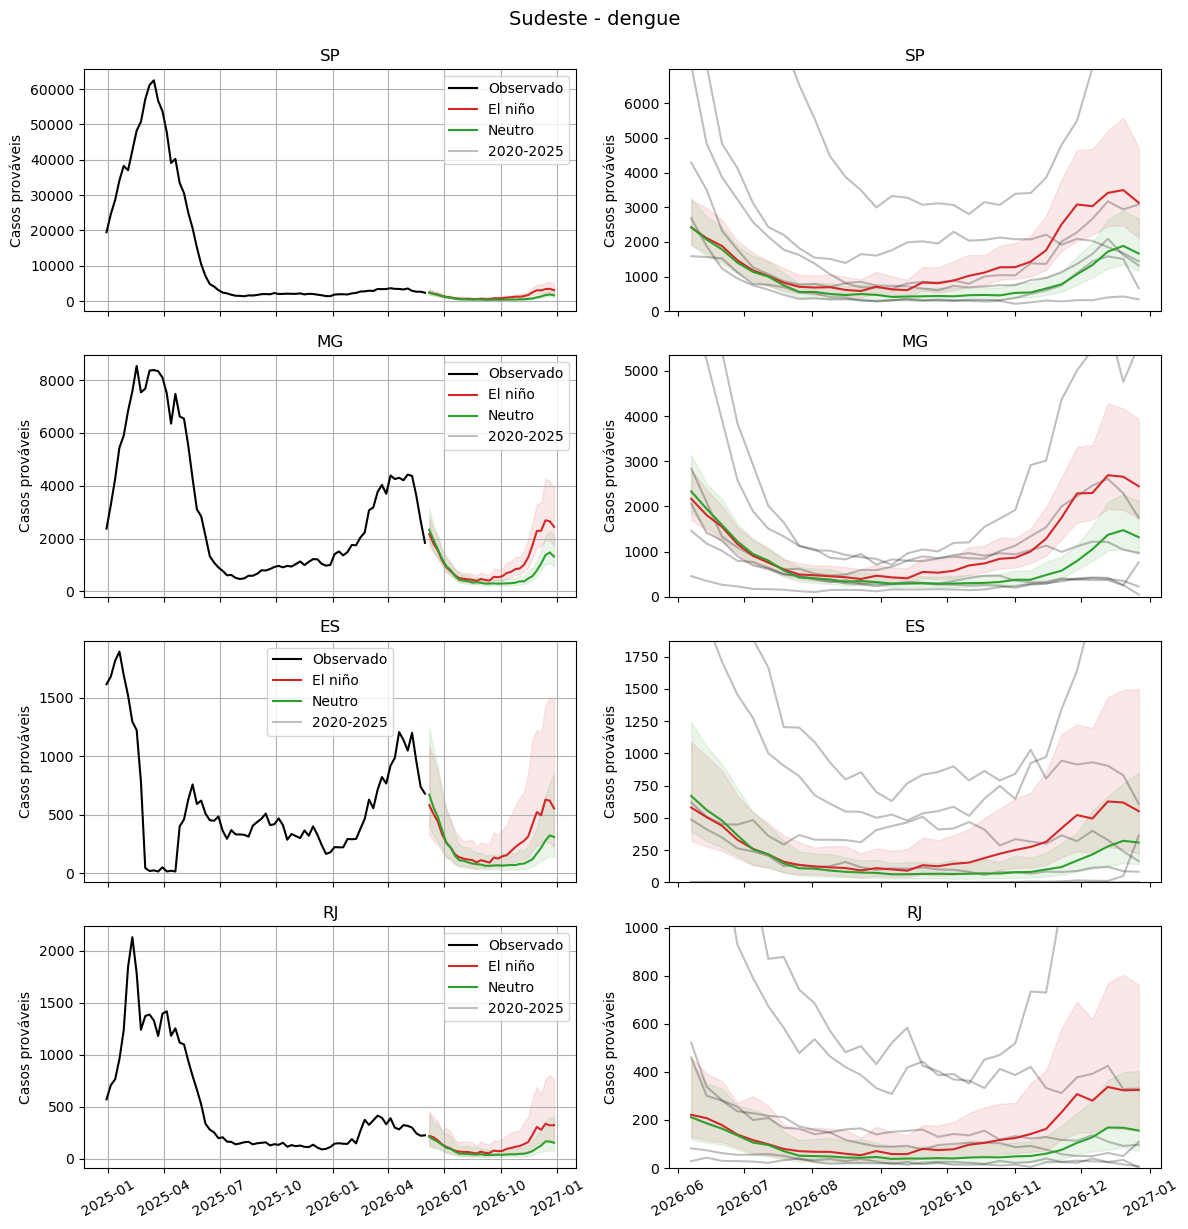

In [7]:
_,ax = plt.subplots(4,2, figsize = (12, 12), sharey = False, sharex = False)

i = 0
for r in ['SP', 'MG', 'ES', 'RJ']: 

    make_figure(ax[i, 0], df, r, TEST_YEAR, model_name)
    ax[i,0].tick_params(axis='x', rotation=30)

    make_figure2(ax[i, 1], df, r, TEST_YEAR, model_name)
    ax[i,1].tick_params(axis='x', rotation=30)


    handles1, labels1 = ax[i,0].get_legend_handles_labels()
    handles2, labels2 = ax[i,1].get_legend_handles_labels()

    # combina
    handles = handles1 + handles2
    labels = labels1 + labels2

    # remove duplicados preservando ordem
    unique = dict(zip(labels, handles))

    # cria legenda única
    ax[i, 0].legend(unique.values(), unique.keys(), loc="best")

    if i < 3: 
        ax[i,0].set_xticklabels([])
        ax[i,1].set_xticklabels([])


    i = i +1


plt.tight_layout()
plt.suptitle(f'Sudeste - {doenca}', y = 1.02, fontsize = 14)
plt.savefig(f'figures/forecast_state_sudeste_zoom_{doenca}.png', dpi = 300, bbox_inches = 'tight')

plt.show()

### Total cases: 

In [15]:
df_total1 = pd.read_csv(f'predictions/preds_total_state_{doenca}_{TEST_YEAR}_{model_name}.csv')
df_total2 = pd.read_csv(f'predictions/preds_neutro_total_state_{doenca}_{TEST_YEAR}_{model_name}.csv')
df_total2['model_name'] = 'Neutro'

df_end = pd.concat([df_total1, df_total2], ignore_index=True)

df_end.head()

,pred,lower_50,upper_50,lower_80,upper_80,lower_90,upper_90,lower_95,upper_95,state,model_name
0,2408.2880,2027.539,2902.9536,1836.3578,3504.7053,1717.4602,3821.8872,1622.7969,4477.2090,SC,El niño
1,8601.8140,7816.324,9713.5150,7138.4320,10927.9030,6872.7400,11516.9630,6632.5850,13036.6420,PR,El niño
2,2711.5488,2407.586,3072.0630,2208.9220,3494.5886,2119.0334,3721.0650,2003.2534,4193.0674,RS,El niño
3,47889.2200,44954.473,51748.2500,42326.7850,55023.2100,40908.7400,57872.3200,39970.0230,59660.1500,SP,El niño
4,35964.7500,33674.670,38392.6800,32243.5040,41341.7100,31465.9000,42488.6760,30682.2050,43104.8300,MG,El niño


In [16]:
df_end_sul = df_end.loc[df_end.state.isin(['SC', 'PR', 'RS'])]

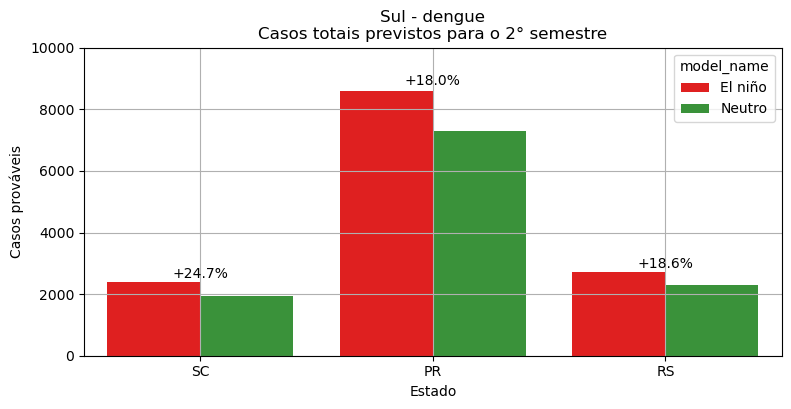

In [20]:
_,ax = plt.subplots(figsize = (9, 4))

sns.barplot(data=df_end_sul, ax=ax, hue='model_name', x='state', y = 'pred', palette=['red', 'tab:green'])

for i, region in enumerate(df_end_sul['state'].unique()):

    df_r = df_end[df_end['state'] == region]

    v1 = df_r.loc[df_r.model_name == 'Neutro']['pred'].values[0]
    v2 = df_r.loc[df_r.model_name == 'El niño']['pred'].values[0]

    pct = 100 * (v2 - v1) / v1

    y = max(v1, v2)

    ax.text(
        i,                  # centro do grupo
        y * 1.01,           # um pouco acima da barra mais alta
        f'{pct:+.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )


#ax.set_ylim([0, 210000])
ax.set_ylim([0, 10000])

ax.grid()
ax.set_xlabel('Estado')
ax.set_ylabel('Casos prováveis')
ax.set_title('Sul - dengue\nCasos totais previstos para o 2° semestre')
plt.savefig(f'figures/total_cases_all_regions_sul_{doenca}.png', dpi = 400, bbox_inches = 'tight')
plt.show()

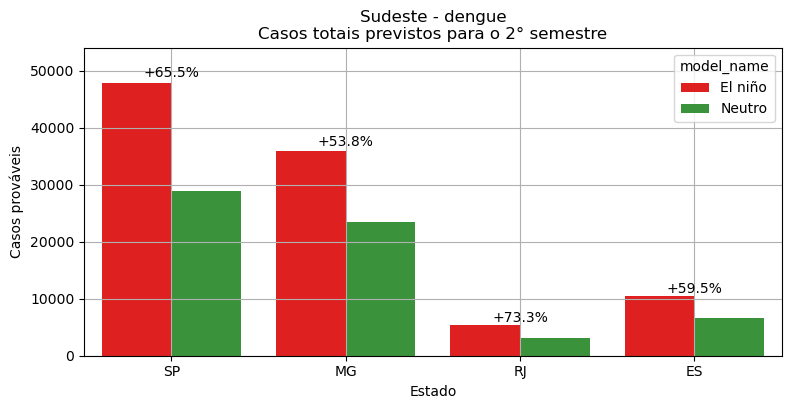

In [25]:
df_end_sud = df_end.loc[df_end.state.isin(['MG', 'RJ', 'ES', 'SP'])]

_,ax = plt.subplots(figsize = (9, 4))

sns.barplot(data=df_end_sud, ax=ax, hue='model_name', x='state', y = 'pred', palette=['red', 'tab:green'])

for i, region in enumerate(df_end_sud['state'].unique()):

    df_r = df_end[df_end['state'] == region]

    v1 = df_r.loc[df_r.model_name == 'Neutro']['pred'].values[0]
    v2 = df_r.loc[df_r.model_name == 'El niño']['pred'].values[0]

    pct = 100 * (v2 - v1) / v1

    y = max(v1, v2)

    ax.text(
        i,                  # centro do grupo
        y * 1.01,           # um pouco acima da barra mais alta
        f'{pct:+.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )


#ax.set_ylim([0, 210000])
ax.set_ylim([0, 54000])

ax.grid()
ax.set_xlabel('Estado')
ax.set_ylabel('Casos prováveis')
ax.set_title('Sudeste - dengue\nCasos totais previstos para o 2° semestre')
plt.savefig(f'figures/total_cases_all_regions_sud_{doenca}.png', dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
#